In [6]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("NIGERIA_WFP_ADMIN1.csv", sep=None, engine="python")
df["time"] = pd.to_datetime(df["time"], errors="coerce", dayfirst=True)
df = df.dropna(subset=["time", "NAME_1"])
df["year"] = df["time"].dt.year

# NDVI: prends celui que tu as (vim)
df["ndvi"] = df["vim"]

# On filtre la qualité NDVI
df = df[df["viq"] >= 80].copy()   

df = df.sort_values(["NAME_1", "time"])
df.head(5)

,time,NAME_1,inadequate,bnds,Y,X,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,Psurf_f_tavg,...,SoilMoi40_100cm_tavg,SoilMoi100_200cm_tavg,SoilTemp00_10cm_tavg,SoilTemp10_40cm_tavg,SoilTemp40_100cm_tavg,SoilTemp100_200cm_tavg,vim,viq,year,ndvi
0,2023-01-01,Abia,0.296774,0.5,5.395,7.471889,0.000016,385.566324,-71.064699,99941.271400,...,0.374807,0.389133,300.138219,299.605325,299.121555,298.700373,0.569790,101.510920,2023,0.569790
28,2023-01-02,Abia,0.401515,0.5,5.395,7.471889,0.000014,392.934595,-69.757725,99864.297600,...,0.365446,0.375858,301.087698,300.549694,300.019129,299.368246,0.598635,100.312830,2023,0.598635
56,2023-01-03,Abia,0.281046,0.5,5.395,7.471889,0.000026,408.719824,-44.999965,99913.329933,...,0.379434,0.378395,299.624543,299.767199,299.874593,299.740318,0.683211,102.223080,2023,0.683211
84,2023-01-04,Abia,0.300613,0.5,5.395,7.471889,0.000030,416.609924,-39.776577,99798.052400,...,0.396723,0.403678,299.950588,299.849166,299.700418,299.525405,0.751135,102.335600,2023,0.751135
112,2023-01-05,Abia,0.226667,0.5,5.395,7.471889,0.000039,419.145751,-35.249339,99990.250067,...,0.413261,0.422155,299.604193,299.639713,299.624382,299.501924,0.790905,102.097565,2023,0.790905


In [45]:
df['Rainf_f_tavg'].mean()

np.float64(4.2265244716173286e-05)

In [8]:
df["month"] = df["time"].astype(str).str.split("-").str[2].astype(int)
df["year"]  = df["time"].astype(str).str.split("-").str[0].astype(int)

df.head(5)

,time,NAME_1,inadequate,bnds,Y,X,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,Psurf_f_tavg,...,SoilMoi100_200cm_tavg,SoilTemp00_10cm_tavg,SoilTemp10_40cm_tavg,SoilTemp40_100cm_tavg,SoilTemp100_200cm_tavg,vim,viq,year,ndvi,month
0,2023-01-01,Abia,0.296774,0.5,5.395,7.471889,0.000016,385.566324,-71.064699,99941.271400,...,0.389133,300.138219,299.605325,299.121555,298.700373,0.569790,101.510920,2023,0.569790,1
28,2023-01-02,Abia,0.401515,0.5,5.395,7.471889,0.000014,392.934595,-69.757725,99864.297600,...,0.375858,301.087698,300.549694,300.019129,299.368246,0.598635,100.312830,2023,0.598635,2
56,2023-01-03,Abia,0.281046,0.5,5.395,7.471889,0.000026,408.719824,-44.999965,99913.329933,...,0.378395,299.624543,299.767199,299.874593,299.740318,0.683211,102.223080,2023,0.683211,3
84,2023-01-04,Abia,0.300613,0.5,5.395,7.471889,0.000030,416.609924,-39.776577,99798.052400,...,0.403678,299.950588,299.849166,299.700418,299.525405,0.751135,102.335600,2023,0.751135,4
112,2023-01-05,Abia,0.226667,0.5,5.395,7.471889,0.000039,419.145751,-35.249339,99990.250067,...,0.422155,299.604193,299.639713,299.624382,299.501924,0.790905,102.097565,2023,0.790905,5


In [9]:
ndvi_monthly = (
    df.groupby(["NAME_1", "month"], as_index=False)
      .agg(ndvi_mean=("vim", "mean"),
           n_obs=("vim", "size"),
           inadequate=("inadequate","mean"))
      .sort_values(["NAME_1", "month"])
)

ndvi_monthly.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate
0,Abia,1,0.561547,3,0.357967
1,Abia,2,0.597959,3,0.409660
2,Abia,3,0.678959,2,0.315020
3,Abia,4,0.742734,3,0.346308
4,Abia,5,0.780453,3,0.289423
5,Abia,6,0.797064,3,0.277903
6,Abia,7,0.796211,3,0.301968
7,Abia,8,0.800370,3,0.246360
8,Abia,9,0.811505,3,0.254307
9,Abia,10,0.794662,3,0.313025


In [10]:
ndvi_monthly["mean_admin"] = ndvi_monthly.groupby("NAME_1")["ndvi_mean"].transform("mean")
ndvi_monthly.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin
0,Abia,1,0.561547,3,0.357967,0.726753
1,Abia,2,0.597959,3,0.409660,0.726753
2,Abia,3,0.678959,2,0.315020,0.726753
3,Abia,4,0.742734,3,0.346308,0.726753
4,Abia,5,0.780453,3,0.289423,0.726753
5,Abia,6,0.797064,3,0.277903,0.726753
6,Abia,7,0.796211,3,0.301968,0.726753
7,Abia,8,0.800370,3,0.246360,0.726753
8,Abia,9,0.811505,3,0.254307,0.726753
9,Abia,10,0.794662,3,0.313025,0.726753


In [11]:
ndvi_monthly["std_admin"] = ndvi_monthly.groupby("NAME_1")["ndvi_mean"].transform("std")
ndvi_monthly.head(20) 

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925


In [12]:
ndvi_monthly["ndvi_anomaly"] = ((ndvi_monthly["ndvi_mean"]-ndvi_monthly["mean_admin"])/ndvi_monthly["std_admin"])

ndvi_monthly.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354


In [13]:
ndvi_monthly["mean_anomaly_admin"] = (ndvi_monthly.groupby("NAME_1")["ndvi_anomaly"].transform("mean"))
ndvi_monthly.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16


on remarque que faire la moyenne des anomalies n'est pas utile comme elle est égale à 0

In [14]:
q = 0.20  # 20e percentile

# seuil par Etat (répété sur chaque ligne de l'Etat)
ndvi_monthly["ndvi_q20_threshold"] = (
    ndvi_monthly.groupby("NAME_1")["ndvi_anomaly"]
    .transform(lambda s: s.quantile(q))
)

# indicateur NDVI bas
ndvi_monthly["ndvi_low_q20"] = ndvi_monthly["ndvi_anomaly"] < ndvi_monthly["ndvi_q20_threshold"]

ndvi_monthly.head(24)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False


In [ ]:
spi_df = pd.read_csv("SPI.csv", sep=None, engine="python")
print(spi_df.columns)
spi_df.head(20)

Index(['﻿', 'State', 'month', 'SPI_Cum1', 'SPI_Cum3', 'SPI_Cum6', 'year'], dtype='object')


,﻿,State,month,SPI_Cum1,SPI_Cum3,SPI_Cum6,year
0,1,Abia,1,-0.6910,-0.5510,-1.9670,2023
1,2,Abia,2,-1.8340,-1.2190,-1.9820,2023
2,3,Abia,3,0.7490,-0.1740,-0.3740,2023
3,4,Abia,4,-0.0510,-0.0190,-0.3940,2023
4,5,Abia,5,-0.2950,0.0200,-0.3890,2023
5,6,Abia,6,1.3650,0.7390,0.5660,2023
6,7,Abia,7,-0.4620,0.3660,0.3020,2023
7,8,Abia,8,-1.8340,-0.8400,-0.8480,2023
8,9,Abia,9,-0.0660,-1.7480,-1.0120,2023
9,10,Abia,10,-0.2890,-2.1500,-0.9520,2023


In [16]:
spi_df = spi_df.rename(columns={"State": "NAME_1"})

In [17]:

spi_monthly = (
    spi_df.groupby(["NAME_1", "month"], as_index=False)
      .agg(spi_mean=("SPI_Cum1", "mean"),
           n_obs=("SPI_Cum1", "size"))
      .sort_values(["NAME_1", "month"])
)
spi_monthly.head(20)

,NAME_1,month,spi_mean,n_obs
0,Abia,1,-0.329000,3
1,Abia,2,-1.373667,3
2,Abia,3,-0.002333,3
3,Abia,4,0.445333,3
4,Abia,5,-1.099000,3
5,Abia,6,-0.363000,3
6,Abia,7,-0.521000,3
7,Abia,8,-1.828667,3
8,Abia,9,-0.670667,3
9,Abia,10,-1.220333,3


In [18]:
spi_monthly["mean_spi_admin"] = spi_monthly.groupby("NAME_1")["spi_mean"].transform("mean")
spi_monthly.head(20)

,NAME_1,month,spi_mean,n_obs,mean_spi_admin
0,Abia,1,-0.329000,3,-0.649667
1,Abia,2,-1.373667,3,-0.649667
2,Abia,3,-0.002333,3,-0.649667
3,Abia,4,0.445333,3,-0.649667
4,Abia,5,-1.099000,3,-0.649667
5,Abia,6,-0.363000,3,-0.649667
6,Abia,7,-0.521000,3,-0.649667
7,Abia,8,-1.828667,3,-0.649667
8,Abia,9,-0.670667,3,-0.649667
9,Abia,10,-1.220333,3,-0.649667


In [19]:
spi_monthly["std_spi_admin"] = spi_monthly.groupby("NAME_1")["spi_mean"].transform("std")
spi_monthly.head(20) 

,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin
0,Abia,1,-0.329000,3,-0.649667,0.638331
1,Abia,2,-1.373667,3,-0.649667,0.638331
2,Abia,3,-0.002333,3,-0.649667,0.638331
3,Abia,4,0.445333,3,-0.649667,0.638331
4,Abia,5,-1.099000,3,-0.649667,0.638331
5,Abia,6,-0.363000,3,-0.649667,0.638331
6,Abia,7,-0.521000,3,-0.649667,0.638331
7,Abia,8,-1.828667,3,-0.649667,0.638331
8,Abia,9,-0.670667,3,-0.649667,0.638331
9,Abia,10,-1.220333,3,-0.649667,0.638331


In [20]:
spi_monthly["spi_anomaly"] = ((spi_monthly["spi_mean"]-spi_monthly["mean_spi_admin"])/spi_monthly["std_spi_admin"])

spi_monthly.head(20)

,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin,spi_anomaly
0,Abia,1,-0.329000,3,-0.649667,0.638331,0.502352
1,Abia,2,-1.373667,3,-0.649667,0.638331,-1.134208
2,Abia,3,-0.002333,3,-0.649667,0.638331,1.014103
3,Abia,4,0.445333,3,-0.649667,0.638331,1.715411
4,Abia,5,-1.099000,3,-0.649667,0.638331,-0.703919
5,Abia,6,-0.363000,3,-0.649667,0.638331,0.449088
6,Abia,7,-0.521000,3,-0.649667,0.638331,0.201567
7,Abia,8,-1.828667,3,-0.649667,0.638331,-1.847004
8,Abia,9,-0.670667,3,-0.649667,0.638331,-0.032898
9,Abia,10,-1.220333,3,-0.649667,0.638331,-0.893998


In [21]:
spi_monthly2 = spi_monthly.copy(deep=True) #copier df pour faire les lags par la suite 

In [22]:
q = 0.20  # 20e percentile

# seuil par Etat (répété sur chaque ligne de l'Etat)
spi_monthly["spi_q20_threshold"] = (
    spi_monthly.groupby("NAME_1")["spi_anomaly"]
    .transform(lambda s: s.quantile(q))
)

# indicateur SPI bas
spi_monthly["spi_low_q20"] = spi_monthly["spi_anomaly"] < spi_monthly["spi_q20_threshold"]

spi_monthly.head(24)

,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin,spi_anomaly,spi_q20_threshold,spi_low_q20
0,Abia,1,-0.329000,3,-0.649667,0.638331,0.502352,-0.855982,False
1,Abia,2,-1.373667,3,-0.649667,0.638331,-1.134208,-0.855982,True
2,Abia,3,-0.002333,3,-0.649667,0.638331,1.014103,-0.855982,False
3,Abia,4,0.445333,3,-0.649667,0.638331,1.715411,-0.855982,False
4,Abia,5,-1.099000,3,-0.649667,0.638331,-0.703919,-0.855982,False
5,Abia,6,-0.363000,3,-0.649667,0.638331,0.449088,-0.855982,False
6,Abia,7,-0.521000,3,-0.649667,0.638331,0.201567,-0.855982,False
7,Abia,8,-1.828667,3,-0.649667,0.638331,-1.847004,-0.855982,True
8,Abia,9,-0.670667,3,-0.649667,0.638331,-0.032898,-0.855982,False
9,Abia,10,-1.220333,3,-0.649667,0.638331,-0.893998,-0.855982,True


In [23]:
spi_lean2 = sorted(spi_monthly.loc[spi_monthly["spi_low_q20"] == True, "month"].unique())
spi_lean2

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12)]

In [24]:
q2 = 0.80  # 80e percentile

# seuil par Etat (répété sur chaque ligne de l'Etat)
spi_monthly2["spi_q80_threshold"] = (
    spi_monthly2.groupby("NAME_1")["spi_anomaly"]
    .transform(lambda s: s.quantile(q2))
)

# indicateur SPI haut
spi_monthly2["spi_high_q80"] = spi_monthly2["spi_anomaly"] > spi_monthly2["spi_q80_threshold"]

spi_monthly2.head(24)

,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin,spi_anomaly,spi_q80_threshold,spi_high_q80
0,Abia,1,-0.329000,3,-0.649667,0.638331,0.502352,0.688671,False
1,Abia,2,-1.373667,3,-0.649667,0.638331,-1.134208,0.688671,False
2,Abia,3,-0.002333,3,-0.649667,0.638331,1.014103,0.688671,True
3,Abia,4,0.445333,3,-0.649667,0.638331,1.715411,0.688671,True
4,Abia,5,-1.099000,3,-0.649667,0.638331,-0.703919,0.688671,False
5,Abia,6,-0.363000,3,-0.649667,0.638331,0.449088,0.688671,False
6,Abia,7,-0.521000,3,-0.649667,0.638331,0.201567,0.688671,False
7,Abia,8,-1.828667,3,-0.649667,0.638331,-1.847004,0.688671,False
8,Abia,9,-0.670667,3,-0.649667,0.638331,-0.032898,0.688671,False
9,Abia,10,-1.220333,3,-0.649667,0.638331,-0.893998,0.688671,False


In [25]:
spi_lean3 = sorted(spi_monthly2.loc[spi_monthly2["spi_high_q80"] == True, "month"].unique())
spi_lean3

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12)]

In [26]:
spi_monthly2.groupby("NAME_1")["spi_high_q80"].mean().describe()

count    37.000000
mean      0.231982
std       0.034778
min       0.166667
25%       0.250000
50%       0.250000
75%       0.250000
max       0.250000
Name: spi_high_q80, dtype: float64

In [27]:
panel = ndvi_monthly.merge(
    spi_monthly[["NAME_1","month","spi_mean","spi_anomaly","spi_q20_threshold","spi_low_q20"]],
    on=["NAME_1","month"],
    how="left"
)

panel.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q20_threshold,spi_low_q20
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True,-0.329000,0.502352,-0.855982,False
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,-0.855982,True
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False,-0.002333,1.014103,-0.855982,False
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False,0.445333,1.715411,-0.855982,False
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False,-1.099000,-0.703919,-0.855982,False
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False,-0.363000,0.449088,-0.855982,False
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False,-0.521000,0.201567,-0.855982,False
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False,-1.828667,-1.847004,-0.855982,True
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False,-0.670667,-0.032898,-0.855982,False
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False,-1.220333,-0.893998,-0.855982,True


In [28]:
panel["lean_risk"] = (panel["ndvi_low_q20"] & panel["spi_low_q20"]).astype(int)

panel.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q20_threshold,spi_low_q20,lean_risk
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True,-0.329000,0.502352,-0.855982,False,0
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,-0.855982,True,1
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False,-0.002333,1.014103,-0.855982,False,0
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False,0.445333,1.715411,-0.855982,False,0
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False,-1.099000,-0.703919,-0.855982,False,0
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False,-0.363000,0.449088,-0.855982,False,0
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False,-0.521000,0.201567,-0.855982,False,0
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False,-1.828667,-1.847004,-0.855982,True,0
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False,-0.670667,-0.032898,-0.855982,False,0
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False,-1.220333,-0.893998,-0.855982,True,0


In [29]:
panel_true = panel[panel["lean_risk"] == 1] 
panel_true.head(50)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q20_threshold,spi_low_q20,lean_risk
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,-0.855982,True,1
25,Adamawa,2,0.265666,3,0.459378,0.444814,0.149927,-1.194901,-1.572816e-16,-1.022038,True,-1.111000,-1.965379,-0.777021,True,1
37,Akwa Ibom,2,0.613420,3,0.372335,0.726390,0.072456,-1.559155,-2.498002e-16,-0.884774,True,-0.770472,-0.568307,-0.552233,True,1
75,Borno,4,0.229505,3,0.530465,0.381199,0.151697,-0.999975,-9.251859e-18,-0.888941,True,-0.477429,-1.287778,-0.583687,True,1
85,Cross River,2,0.630823,3,0.353008,0.740000,0.070869,-1.540539,5.366078e-16,-0.897476,True,-1.038833,-1.001153,-0.542937,True,1
136,Jigawa,4,0.215138,3,0.500091,0.332157,0.119288,-0.980985,-2.544261e-16,-0.884110,True,-1.246389,-1.967701,-0.494398,True,1
160,Kano,4,0.209998,3,0.478991,0.356833,0.162562,-0.903259,8.326673e-17,-0.850629,True,-0.663000,-1.277509,-1.106474,True,1
172,Katsina,4,0.204218,3,0.514650,0.356279,0.156941,-0.968912,1.480297e-16,-0.873082,True,0.061167,-0.976974,-0.620527,True,1
207,Kwara,3,0.381185,2,0.365075,0.552560,0.154410,-1.109868,4.625929e-17,-1.047521,True,-0.630500,-1.053552,-0.738307,True,1
228,Lagos,12,0.543276,3,0.332052,0.604390,0.056953,-1.073048,-5.551115e-16,-0.964799,True,-0.170333,-0.703570,-0.658331,True,1


In [30]:
months_lean = sorted(panel.loc[panel["lean_risk"] == 1, "month"].unique())
months_lean

[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(12)]

In [31]:
month_counts = (panel.loc[panel["lean_risk"] == 1]#combien d'états touchés par mois
                .groupby("month")["NAME_1"]
                .nunique()
                .sort_index())
month_counts 

month
2     4
3     1
4     5
5     1
12    1
Name: NAME_1, dtype: int64

In [32]:
panel2 = ndvi_monthly.merge(
    spi_monthly2[["NAME_1","month","spi_mean","spi_anomaly","spi_q80_threshold","spi_high_q80"]],
    on=["NAME_1","month"],
    how="left"
)

panel2.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q80_threshold,spi_high_q80
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True,-0.329000,0.502352,0.688671,False
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,0.688671,False
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False,-0.002333,1.014103,0.688671,True
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False,0.445333,1.715411,0.688671,True
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False,-1.099000,-0.703919,0.688671,False
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False,-0.363000,0.449088,0.688671,False
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False,-0.521000,0.201567,0.688671,False
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False,-1.828667,-1.847004,0.688671,False
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False,-0.670667,-0.032898,0.688671,False
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False,-1.220333,-0.893998,0.688671,False


In [33]:
panel2["lean_rain_high_veg_low"] = (panel2["spi_high_q80"] & panel2["ndvi_low_q20"]).astype(int)

panel2.head(20)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q80_threshold,spi_high_q80,lean_rain_high_veg_low
0,Abia,1,0.561547,3,0.357967,0.726753,0.087925,-1.878941,-3.145632e-16,-0.959919,True,-0.329000,0.502352,0.688671,False,0
1,Abia,2,0.597959,3,0.409660,0.726753,0.087925,-1.464822,-3.145632e-16,-0.959919,True,-1.373667,-1.134208,0.688671,False,0
2,Abia,3,0.678959,2,0.315020,0.726753,0.087925,-0.543580,-3.145632e-16,-0.959919,False,-0.002333,1.014103,0.688671,True,0
3,Abia,4,0.742734,3,0.346308,0.726753,0.087925,0.181765,-3.145632e-16,-0.959919,False,0.445333,1.715411,0.688671,True,0
4,Abia,5,0.780453,3,0.289423,0.726753,0.087925,0.610754,-3.145632e-16,-0.959919,False,-1.099000,-0.703919,0.688671,False,0
5,Abia,6,0.797064,3,0.277903,0.726753,0.087925,0.799669,-3.145632e-16,-0.959919,False,-0.363000,0.449088,0.688671,False,0
6,Abia,7,0.796211,3,0.301968,0.726753,0.087925,0.789975,-3.145632e-16,-0.959919,False,-0.521000,0.201567,0.688671,False,0
7,Abia,8,0.800370,3,0.246360,0.726753,0.087925,0.837270,-3.145632e-16,-0.959919,False,-1.828667,-1.847004,0.688671,False,0
8,Abia,9,0.811505,3,0.254307,0.726753,0.087925,0.963916,-3.145632e-16,-0.959919,False,-0.670667,-0.032898,0.688671,False,0
9,Abia,10,0.794662,3,0.313025,0.726753,0.087925,0.772354,-3.145632e-16,-0.959919,False,-1.220333,-0.893998,0.688671,False,0


In [34]:
panel_true2 = panel2[panel2["lean_rain_high_veg_low"] == 1] 
panel_true2.head(50)

,NAME_1,month,ndvi_mean,n_obs,inadequate,mean_admin,std_admin,ndvi_anomaly,mean_anomaly_admin,ndvi_q20_threshold,ndvi_low_q20,spi_mean,spi_anomaly,spi_q80_threshold,spi_high_q80,lean_rain_high_veg_low
11,Abia,12,0.633201,3,0.381811,0.726753,0.087925,-1.064004,-3.145632e-16,-0.959919,True,-0.180333,0.735251,0.688671,True,1
13,Abuja,2,0.292107,3,0.288947,0.533885,0.171904,-1.406470,-1.295260e-16,-1.113462,True,0.666667,1.887275,0.670726,True,1
14,Abuja,3,0.323778,2,0.312745,0.533885,0.171904,-1.222234,-1.295260e-16,-1.113462,True,0.047167,0.671609,0.670726,True,1
47,Akwa Ibom,12,0.657028,3,0.362620,0.726390,0.072456,-0.957296,-2.498002e-16,-0.884774,True,0.011083,0.766594,0.743365,True,1
60,Benue,1,0.368242,3,0.454139,0.573351,0.143145,-1.432875,1.480297e-16,-1.081543,True,0.029111,0.916865,0.827293,True,1
84,Cross River,1,0.614244,3,0.349539,0.740000,0.070869,-1.774477,5.366078e-16,-0.897476,True,-0.115500,0.754635,0.695496,True,1
95,Cross River,12,0.673410,3,0.307047,0.740000,0.070869,-0.939623,5.366078e-16,-0.897476,True,0.220833,1.394198,0.695496,True,1
108,Edo,12,0.626242,3,0.382662,0.722802,0.096366,-1.002014,4.810966e-16,-0.938578,True,-0.107833,1.042474,0.820128,True,1
120,Enugu,12,0.559134,3,0.390997,0.665063,0.111531,-0.949765,6.198745e-16,-0.936515,True,0.024667,1.078121,0.909546,True,1
135,Jigawa,3,0.224857,2,0.608522,0.332157,0.119288,-0.899511,-2.544261e-16,-0.884110,True,2.087833,1.922765,0.474847,True,1


In [35]:
months_lean2 = sorted(panel2.loc[panel2["lean_rain_high_veg_low"] == 1, "month"].unique())
months_lean2

[np.int64(1), np.int64(2), np.int64(3), np.int64(12)]

## Methode 2 : Détermination des lean seasons à partir de la variable rainfall

In [37]:
df.columns

Index(['time', 'NAME_1', 'inadequate', 'bnds', 'Y', 'X', 'Evap_tavg',
       'LWdown_f_tavg', 'Lwnet_tavg', 'Psurf_f_tavg', 'Qair_f_tavg', 'Qg_tavg',
       'Qh_tavg', 'Qle_tavg', 'Qs_tavg', 'RadT_tavg', 'Rainf_f_tavg',
       'SWdown_f_tavg', 'Swnet_tavg', 'Tair_f_tavg', 'Wind_f_tavg',
       'SoilMoi00_10cm_tavg', 'SoilMoi10_40cm_tavg', 'SoilMoi40_100cm_tavg',
       'SoilMoi100_200cm_tavg', 'SoilTemp00_10cm_tavg', 'SoilTemp10_40cm_tavg',
       'SoilTemp40_100cm_tavg', 'SoilTemp100_200cm_tavg', 'vim', 'viq', 'year',
       'ndvi', 'month'],
      dtype='object')

In [ ]:
rainf_f_monthly = (
    df.groupby(["NAME_1", "month"], as_index=False)
      .agg(rainf_f_mean=("Rainf_f_tavg", "mean"),
           n_obs=("Rainf_f_tavg", "size"))
      .sort_values(["NAME_1", "month"])
)

rainf_f_monthly["rainf_f_mean_admin"] = spi_monthly.groupby("NAME_1")["rainf_f_mean"].transform("mean")
rainf_f_monthly.head(20)

,NAME_1,month,rainf_f_mean,n_obs,rainf_f_mean_admin
0,Abia,1,5.462783e-06,3,0.000068
1,Abia,2,1.054666e-05,3,0.000068
2,Abia,3,5.165889e-05,2,0.000068
3,Abia,4,5.211637e-05,3,0.000068
4,Abia,5,8.865756e-05,3,0.000068
5,Abia,6,1.126842e-04,3,0.000068
6,Abia,7,1.221564e-04,3,0.000068
7,Abia,8,7.254241e-05,3,0.000068
8,Abia,9,1.245377e-04,3,0.000068
9,Abia,10,1.036493e-04,3,0.000068


## Méthode 3 : Détermination des Lean Season avec SPI et NDVI haut 

In [79]:
#Création des variables : 

q = 0.80  # 20e percentile

# seuil par Etat (répété sur chaque ligne de l'Etat)
spi_monthly["spi_q80_threshold"] = (
    spi_monthly.groupby("NAME_1")["spi_anomaly"]
    .transform(lambda s: s.quantile(q))
)

# indicateur SPI haut
spi_monthly["spi_hi_q80"] = spi_monthly["spi_anomaly"] > spi_monthly["spi_q80_threshold"]

spi_monthly.head(24)



,NAME_1,month,spi_mean,n_obs,mean_spi_admin,std_spi_admin,spi_anomaly,spi_q20_threshold,spi_low_q20,spi_q90_threshold,spi_hi_q90,spi_q80_threshold,spi_hi_q80
0,Abia,1,-0.329000,3,-0.649667,0.638331,0.502352,-0.855982,False,0.688671,False,0.688671,False
1,Abia,2,-1.373667,3,-0.649667,0.638331,-1.134208,-0.855982,True,0.688671,False,0.688671,False
2,Abia,3,-0.002333,3,-0.649667,0.638331,1.014103,-0.855982,False,0.688671,True,0.688671,True
3,Abia,4,0.445333,3,-0.649667,0.638331,1.715411,-0.855982,False,0.688671,True,0.688671,True
4,Abia,5,-1.099000,3,-0.649667,0.638331,-0.703919,-0.855982,False,0.688671,False,0.688671,False
5,Abia,6,-0.363000,3,-0.649667,0.638331,0.449088,-0.855982,False,0.688671,False,0.688671,False
6,Abia,7,-0.521000,3,-0.649667,0.638331,0.201567,-0.855982,False,0.688671,False,0.688671,False
7,Abia,8,-1.828667,3,-0.649667,0.638331,-1.847004,-0.855982,True,0.688671,False,0.688671,False
8,Abia,9,-0.670667,3,-0.649667,0.638331,-0.032898,-0.855982,False,0.688671,False,0.688671,False
9,Abia,10,-1.220333,3,-0.649667,0.638331,-0.893998,-0.855982,True,0.688671,False,0.688671,False


In [80]:
q = 0.80 
# indicateur NDVI haut
ndvi_monthly["ndvi_q80_threshold"] = (
    ndvi_monthly.groupby("NAME_1")["ndvi_anomaly"]
    .transform(lambda s: s.quantile(q))
)
ndvi_monthly["ndvi_hi_q80"] = ndvi_monthly["ndvi_anomaly"] > ndvi_monthly["ndvi_q80_threshold"]


In [81]:
# Création du data frame sommaire - SPI 
# On groupe par admin et par mois, puis on somme le flag binaire
SPI_summary = spi_monthly.groupby(['NAME_1', 'month'])['spi_hi_q90'].sum().reset_index()

# On renomme la colonne pour plus de clarté
SPI_summary.rename(columns={'spi_hi_q90': 'spi_hi_count'}, inplace=True)

# Affichage du résultat
SPI_summary.head(10)

,NAME_1,month,spi_hi_count
0,Abia,1,0
1,Abia,2,0
2,Abia,3,1
3,Abia,4,1
4,Abia,5,0
5,Abia,6,0
6,Abia,7,0
7,Abia,8,0
8,Abia,9,0
9,Abia,10,0


In [82]:
# Création du data frame sommaire - NDVI 
# On groupe par admin et par mois, puis on somme le flag binaire
ndvi_summary = ndvi_monthly.groupby(['NAME_1', 'month'])['ndvi_hi_q80'].sum().reset_index()

# On renomme la colonne pour plus de clarté
ndvi_summary.rename(columns={'ndvi_hi_q80': 'ndvi_hi_count'}, inplace=True)

# Affichage du résultat
ndvi_summary.head(10)

,NAME_1,month,ndvi_hi_count
0,Abia,1,0
1,Abia,2,0
2,Abia,3,0
3,Abia,4,0
4,Abia,5,0
5,Abia,6,1
6,Abia,7,0
7,Abia,8,1
8,Abia,9,1
9,Abia,10,0


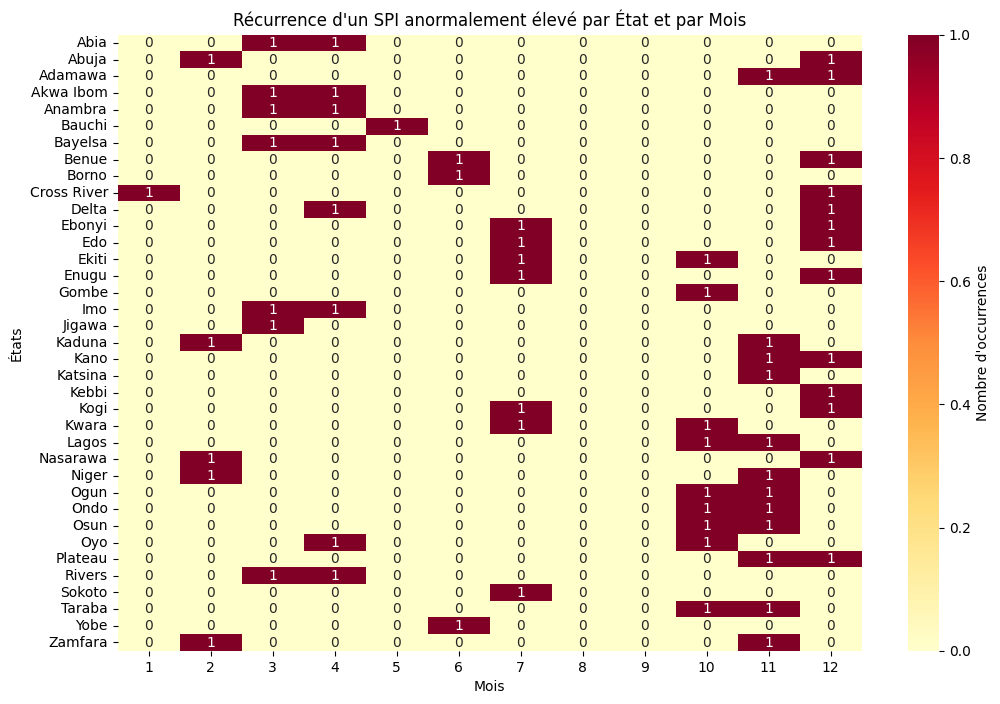

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

## HEATMAP SPI 

# 1. On pivote les données pour créer la matrice (États en lignes, Mois en colonnes)
# Assurez-vous que 'spi_hi_count' est bien le nom de votre colonne de compteur
pivot_df_SPI = SPI_summary.pivot(index="NAME_1", columns="month", values="spi_hi_count")

# 2. Création du heatmap avec la correction du label de légende
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, 
            annot=True, 
            cmap="YlOrRd", 
            cbar_kws={'label': "Nombre d'occurrences"})

plt.title("Récurrence d'un SPI anormalement élevé par État et par Mois")
plt.xlabel("Mois")
plt.ylabel("États")

plt.savefig("heatmap_lean_season.png") # Sauvegarde pour votre rapport
plt.show()

In [75]:
pivot_df.head(5)

month,1,2,3,4,5,6,7,8,9,10,11,12
NAME_1,,,,,,,,,,,,
Abia,0,0,1,1,0,0,0,0,0,0,0,0
Abuja,0,1,0,0,0,0,0,0,0,0,0,1
Adamawa,0,0,0,0,0,0,0,0,0,0,1,1
Akwa Ibom,0,0,1,1,0,0,0,0,0,0,0,0
Anambra,0,0,1,1,0,0,0,0,0,0,0,0


In [76]:
pivot_df.sum()

month
1      1
2      5
3      7
4      8
5      1
6      3
7      7
8      0
9      0
10     9
11    12
12    13
dtype: int64

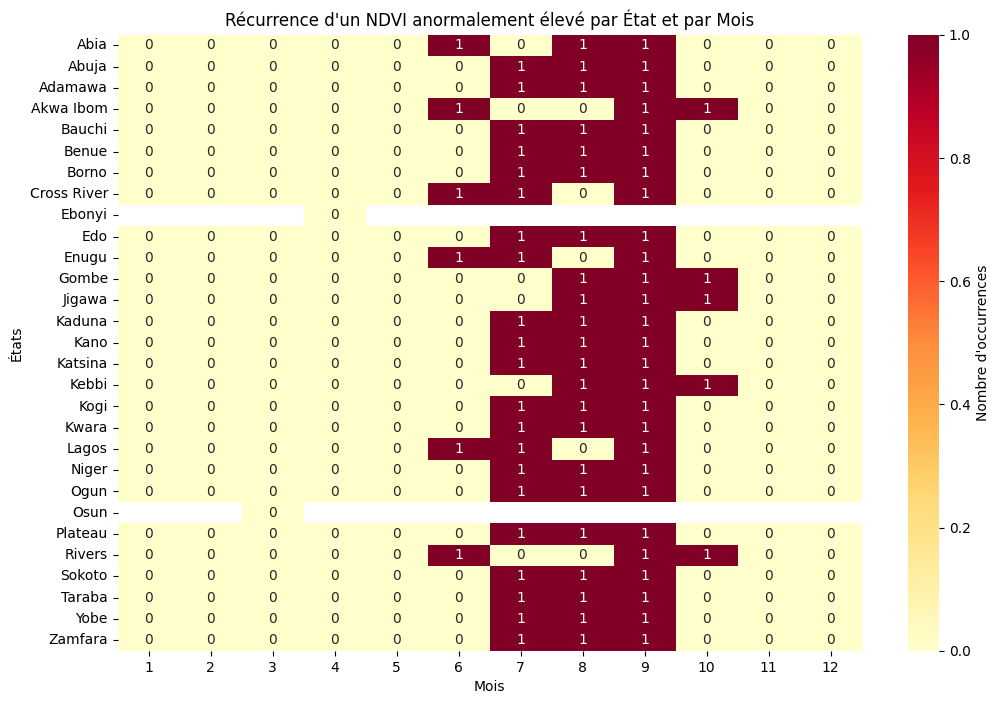

In [77]:

## HEATMAP NDVI 

# 1. On pivote les données pour créer la matrice (États en lignes, Mois en colonnes)
# Assurez-vous que 'spi_hi_count' est bien le nom de votre colonne de compteur
pivot_df_ndvi = ndvi_summary.pivot(index="NAME_1", columns="month", values="ndvi_hi_count")

# 2. Création du heatmap avec la correction du label de légende
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df_ndvi, 
            annot=True, 
            cmap="YlOrRd", 
            cbar_kws={'label': "Nombre d'occurrences"})

plt.title("Récurrence d'un NDVI anormalement élevé par État et par Mois")
plt.xlabel("Mois")
plt.ylabel("États")

plt.savefig("heatmap_ndvi.png") # Sauvegarde pour votre rapport
plt.show()

L'indicateur qui consiste a utiliser l'intersection de NDVI et SPI haut ne convient pas car il implique que seul le mois de juillet ferait partie de la lean season. Les deux heatmaps précedentes nous permettent de supposer que la période de risque maximale est atteinte en Juillet car les deux conditions : Stocks alimentaires écoulées et précipitations sont cumulées.

La limite de cet indicateur est qu'il ne permet pas de définir une période de soudure mais une période où les cultures sont accessibles mais où la pluie empêche les récoltes et sature les sols 

## Méthode 3 : Intersection entre la croissance de la végetation et pluies hautes


In [ ]:
# Création du data frame pour NDVI, par an 
ndvi_yearly = (
    df.groupby(["NAME_1", "month","year"], as_index=False)
      .agg(ndvi=("vim", "mean"),
           n_obs=("vim", "size"),
           inadequate=("inadequate","mean"))
      .sort_values(["NAME_1", "month"])
)

ndvi_yearly["ndvi_mean_admin"] = ndvi_yearly.groupby("NAME_1")["ndvi"].transform("mean")
ndvi_yearly["ndvi_std_admin"] = ndvi_yearly.groupby("NAME_1")["ndvi"].transform("std")
ndvi_yearly["ndvi_anom"] = (ndvi_yearly["ndvi"] - ndvi_yearly["ndvi_mean_admin"])/ ndvi_yearly["ndvi_std_admin"]
ndvi_yearly.head(45)


,NAME_1,month,year,ndvi,n_obs,inadequate,ndvi_mean_admin,ndvi_std_admin,ndvi_anom
0,Abia,1,2023,0.569790,1,0.296774,0.728118,0.087077,-1.818256
1,Abia,1,2024,0.567952,1,0.454545,0.728118,0.087077,-1.839369
2,Abia,1,2025,0.546900,1,0.322581,0.728118,0.087077,-2.081131
3,Abia,2,2023,0.598635,1,0.401515,0.728118,0.087077,-1.487003
4,Abia,2,2024,0.602415,1,0.471910,0.728118,0.087077,-1.443585
5,Abia,2,2025,0.592826,1,0.355556,0.728118,0.087077,-1.553714
6,Abia,3,2023,0.683211,1,0.281046,0.728118,0.087077,-0.515724
7,Abia,3,2025,0.674707,1,0.348993,0.728118,0.087077,-0.613386
8,Abia,4,2023,0.751135,1,0.300613,0.728118,0.087077,0.264323
9,Abia,4,2024,0.740771,1,0.462121,0.728118,0.087077,0.145304


In [ ]:
# Création du data frame pour NDVI, par an 
spi_yearly = (
    SPI.groupby(["NAME_1", "month","year"], as_index=False)
      .agg(ndvi=("spi", "mean"),
           n_obs=("vim", "size"),
           inadequate=("inadequate","mean"))
      .sort_values(["NAME_1", "month"])
)

ndvi_yearly["ndvi_mean_admin"] = ndvi_yearly.groupby("NAME_1")["ndvi"].transform("mean")
ndvi_yearly["ndvi_std_admin"] = ndvi_yearly.groupby("NAME_1")["ndvi"].transform("std")
ndvi_yearly["ndvi_anom"] = (ndvi_yearly["ndvi"] - ndvi_yearly["ndvi_mean_admin"])/ ndvi_yearly["ndvi_std_admin"]
ndvi_yearly.head(45)


In [ ]:
ndvi_yearly['ndvi_anom'] = ndvi_yearly[ndvi_yearly['ndvi'] - ndvi_yearly('ndvi')


In [102]:

spi_yearly = (
    spi_df.groupby(["NAME_1", "month","year"], as_index=False)
      .agg(spi=("SPI_Cum1", "mean"),
           n_obs=("SPI_Cum1", "size"))
      .sort_values(["NAME_1", "month"])
)
spi_monthly.head(20)

ndvi_yearly.head(5)

,NAME_1,month,year,ndvi_mean,n_obs,inadequate
0,Abia,1,2023,0.569790,1,0.296774
1,Abia,1,2024,0.567952,1,0.454545
2,Abia,1,2025,0.546900,1,0.322581
3,Abia,2,2023,0.598635,1,0.401515
4,Abia,2,2024,0.602415,1,0.471910


In [101]:
summary_lean_season_yearly = ndvi_yearly.merge(spi_yearly, on=['NAME_1', 'month','year'])
summary_lean_season_yearly.head(5)

,NAME_1,month,year,ndvi_mean,n_obs_x,inadequate,spi_mean,n_obs_y
0,Abia,1,2023,0.569790,1,0.296774,-0.691,1
1,Abia,1,2024,0.567952,1,0.454545,0.002,1
2,Abia,1,2025,0.546900,1,0.322581,-0.298,1
3,Abia,2,2023,0.598635,1,0.401515,-1.834,1
4,Abia,2,2024,0.602415,1,0.471910,-1.834,1


In [ ]:
# On compare la SECOURS (Série) au chiffre 0
summary_lean_season['is_growing_season'] = summary_lean_season['ndvi_anomaly'] > 0 

# 2. Correction de l'opération logique
# On s'assure d'utiliser les colonnes du même DataFrame pour le calcul
summary_lean_season['access_shock'] = (summary_lean_season['is_growing_season']) & (summary_lean_season['spi_hi_q90'])


In [95]:
def compute_max_consecutive_months(group):
    # On transforme les booléens en chaîne de caractères (ex: "001110")
    binary_str = "".join(group['access_shock'].astype(int).astype(str))
    
    # On découpe la chaîne par les "0" pour isoler les blocs de "1"
    runs = binary_str.split('0')
    
    # On calcule la longueur de chaque bloc et on garde le maximum
    return max(len(run) for run in runs) if '1' in binary_str else 0

# Application du calcul par État et par Année
lean_duration = summary_lean_season.groupby(['NAME_1']).apply(compute_max_consecutive_months).reset_index()
lean_duration.columns = ['NAME_1', 'lean_season_length']

/tmp/ipykernel_15829/3824783238.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lean_duration = summary_lean_season.groupby(['NAME_1']).apply(compute_max_consecutive_months).reset_index()
